# Airbnb NYC Price Prediction

**Dataset:** Airbnb Open Data — New York City listings
'https://www.kaggle.com/datasets/arianazmoudeh/airbnbopendata'

**Objective:** Predict listing prices using property attributes, host characteristics, and location features.

**Overview:**
1. Data Loading & Initial Inspection  
2. Data Cleaning  
3. Missing Value Imputation  
4. Feature Engineering  
5. Encoding & Type Conversion  
6. Exploratory Data Analysis  
7. Model Training & Evaluation  
8. Interpretation & Conclusions


## 1. Importing required libraries

In [125]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## 2. Loading the dataset
The dataset is loaded from a CSV file containing Airbnb listing information for New York City.

In [126]:
data=pd.read_csv(r"/content/Airbnb_Open_Data.csv", engine='python')

A quick inspection of the first few rows reveals 26 columns covering listing metadata, pricing, host information, location, and review statistics.

In [127]:
data.head()
data.shape

(102599, 26)

## 3. Data Cleaning
A working copy of the dataset is created to preserve the original data.

In [128]:
df1=data.copy()

### 3.1 Descriptive Statistics
Summary statistics to identify anomalies such as negative values, extreme outliers, and inconsistent ranges.

In [129]:
df1.describe()

,id,host id,lat,long,Construction year,minimum nights,number of reviews,reviews per month,review rate number,calculated host listings count,availability 365
count,1.025990e+05,1.025990e+05,102591.000000,102591.000000,102385.000000,102190.000000,102416.000000,86720.000000,102273.000000,102280.000000,102151.000000
mean,2.914623e+07,4.925411e+10,40.728094,-73.949644,2012.487464,8.135845,27.483743,1.374022,3.279106,7.936605,141.133254
std,1.625751e+07,2.853900e+10,0.055857,0.049521,5.765556,30.553781,49.508954,1.746621,1.284657,32.218780,135.435024
min,1.001254e+06,1.236005e+08,40.499790,-74.249840,2003.000000,-1223.000000,0.000000,0.010000,1.000000,1.000000,-10.000000
25%,1.508581e+07,2.458333e+10,40.688740,-73.982580,2007.000000,2.000000,1.000000,0.220000,2.000000,1.000000,3.000000
50%,2.913660e+07,4.911774e+10,40.722290,-73.954440,2012.000000,3.000000,7.000000,0.740000,3.000000,1.000000,96.000000
75%,4.320120e+07,7.399650e+10,40.762760,-73.932350,2017.000000,5.000000,30.000000,2.000000,4.000000,2.000000,269.000000
max,5.736742e+07,9.876313e+10,40.916970,-73.705220,2022.000000,5645.000000,1024.000000,90.000000,5.000000,332.000000,3677.000000


### 3.2 Handling Invalid Values
Negative entries in minimum nights and availability 365 are not valid quantities and cannot be corrected by sign conversion as they represent data entry errors. These values are replaced with NaN to be handled during the imputation stage.

In [130]:
df1.loc[df1['minimum nights'] < 0, 'minimum nights'] = np.nan
df1.loc[df1['availability 365'] < 0, 'availability 365'] = np.nan

### 3.3 Duplicate Detection

In [131]:
df1.duplicated().sum()

np.int64(541)

In [132]:
df1=df1.drop_duplicates()
df1.shape

(102058, 26)

### 3.4 Categorical Consistency Check
Checking for spelling inconsistencies and redundant columns to prepare the data for one hot encoding

In [133]:
#we observed that two columns, country and country code , are filled only with strings: 'United States of America' and 'US' respectively
print(df1['country'].nunique())
print(df1['country code'].nunique())

1
1


In [134]:
df1.drop(columns=['country','country code'],inplace = True)

In [135]:
df1["neighbourhood group"].unique()

array(['Brooklyn', 'Manhattan', 'brookln', 'manhatan', 'Queens', nan,
       'Staten Island', 'Bronx'], dtype=object)

In [136]:
#Removing repeated spellings and data cleaning
df1['neighbourhood group'] = df1['neighbourhood group'].str.lower().str.strip()

df1['neighbourhood group'] = df1['neighbourhood group'].replace({
    'brookln': 'brooklyn',
    'manhatan': 'manhattan'
})
df1['review rate number'].fillna(df1['review rate number'].median(), inplace=True)

In [137]:
df1["neighbourhood group"].unique()

array(['brooklyn', 'manhattan', 'queens', nan, 'staten island', 'bronx'],
      dtype=object)

Neighbourhood group labels were standardised by converting to lowercase and stripping whitespace. Common variants (e.g., 'brookyln'→ 'brooklyn') were merged to ensure consistent one-hot encoding.

### 3.5 Numeric Columns Stored as Strings
The price and service fee columns are stored as strings with currency symbols. These are stripped and converted to numeric for further processing.

In [138]:
df1['price'] = df1['price'].str.replace('$', '').str.replace(',', '')
df1['service fee'] = df1['service fee'].str.replace('$', '').str.replace(',', '')
#changing datatype of price and service fee
df1['price']=df1['price'].astype('float64')
df1['service fee']=df1['service fee'].astype('float64')

In [139]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 102058 entries, 0 to 102057
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102058 non-null  int64  
 1   NAME                            101808 non-null  object 
 2   host id                         102058 non-null  int64  
 3   host_identity_verified          101769 non-null  object 
 4   host name                       101654 non-null  object 
 5   neighbourhood group             102029 non-null  object 
 6   neighbourhood                   102042 non-null  object 
 7   lat                             102050 non-null  float64
 8   long                            102050 non-null  float64
 9   instant_bookable                101953 non-null  object 
 10  cancellation_policy             101982 non-null  object 
 11  room type                       102058 non-null  object 
 12  Construction year    

## 4. Missing Value Imputation

### 4.1 Comparing Statistical vs. KNN Imputation
To select the most appropriate imputation strategy, median (statistical) imputation is compared against K-Nearest Neighbours (KNN) imputation on numerical columns. Both methods are evaluated visually to assess their impact on the data distribution, and to make a choice between the two.

In [140]:
print(df1.isnull().sum())
print('\nChecking for string-based null representations')
fake_nulls = ['NaN', 'null', 'N/A', 'n/a', '', ' ']
for col in df1.columns:
    fake_count = df1[col].isin(fake_nulls).sum()
    if fake_count>0:
       print(f"{col}-{fake_count}")
    else:
      continue
print('no string based null values')

id                                     0
NAME                                 250
host id                                0
host_identity_verified               289
host name                            404
neighbourhood group                   29
neighbourhood                         16
lat                                    8
long                                   8
instant_bookable                     105
cancellation_policy                   76
room type                              0
Construction year                    214
price                                247
service fee                          273
minimum nights                       413
number of reviews                    183
last review                        15832
reviews per month                  15818
review rate number                     0
calculated host listings count       319
availability 365                     879
house_rules                        51842
license                           102056
dtype: int64

Ch

In [187]:
df_stat = df1.copy()
df_knn = df1.copy()

In [188]:
# Numerical columns
num_cols = df_stat.select_dtypes(include=['int64', 'float64']).columns
# Filling with median
for col in num_cols:
    df_stat[col].fillna(df_stat[col].median(), inplace=True)

# for categorical columns
cat_cols = df_stat.select_dtypes(include='object').columns
for col in cat_cols:
    df_stat[col].fillna(df_stat[col].mode()[0], inplace=True)

In [189]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

# Selecting numeric columns
num_cols = df_knn.select_dtypes(include=['int64', 'float64']).columns

# Scaling data for KNN imputer
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_knn[num_cols])

imputer = KNNImputer(n_neighbors=5)
knn_imputed = imputer.fit_transform(scaled_data)

df_knn[num_cols] = scaler.inverse_transform(knn_imputed)

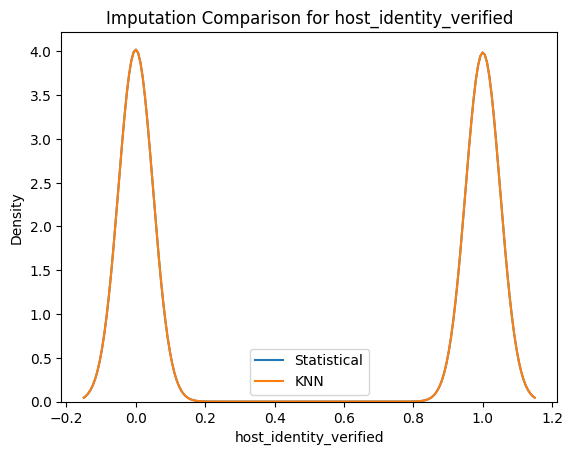

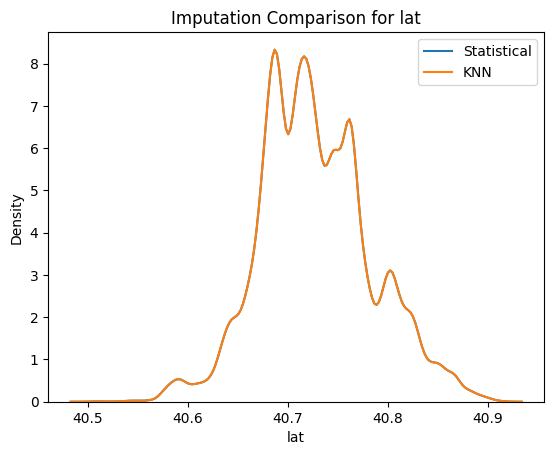

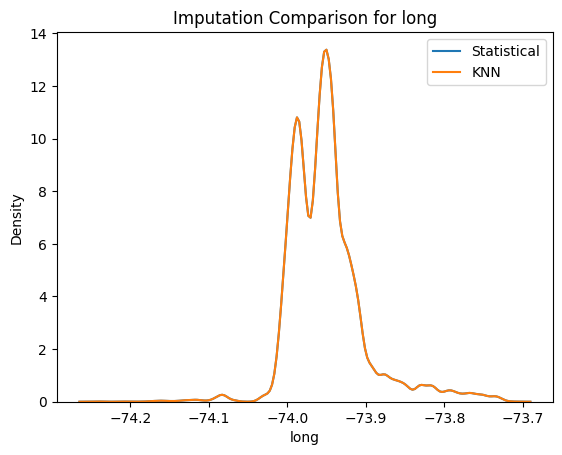

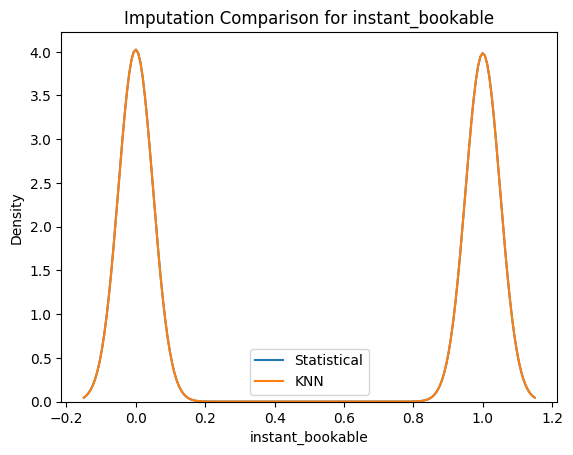

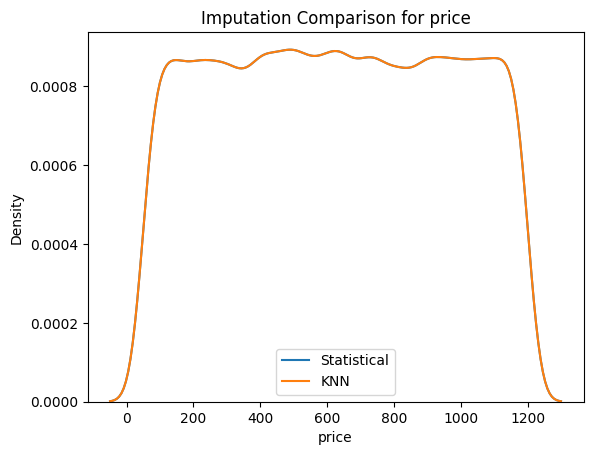

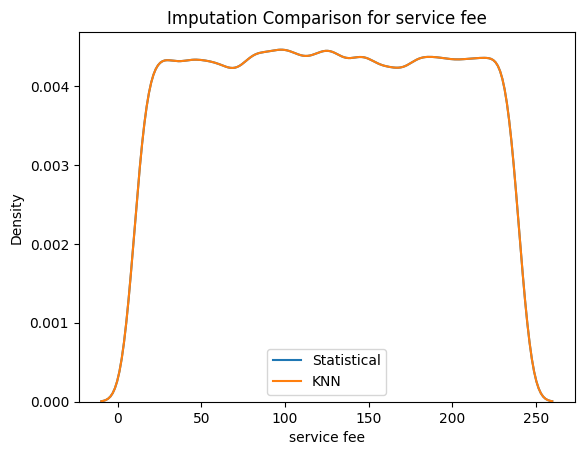

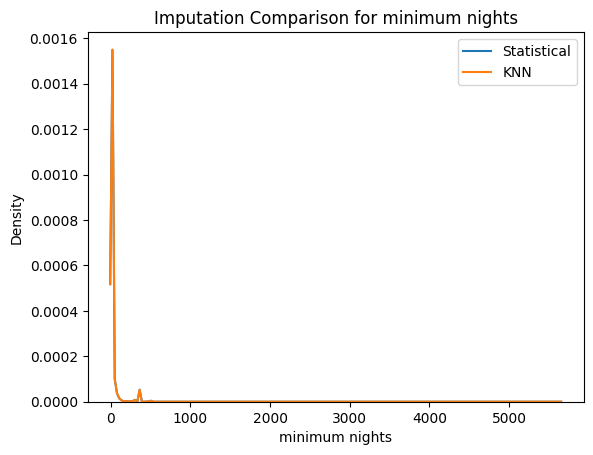

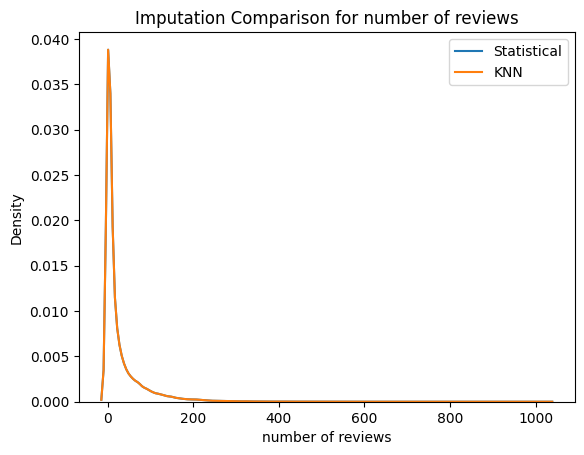

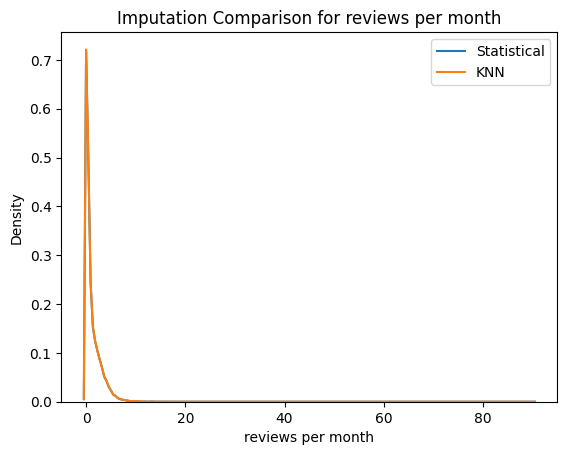

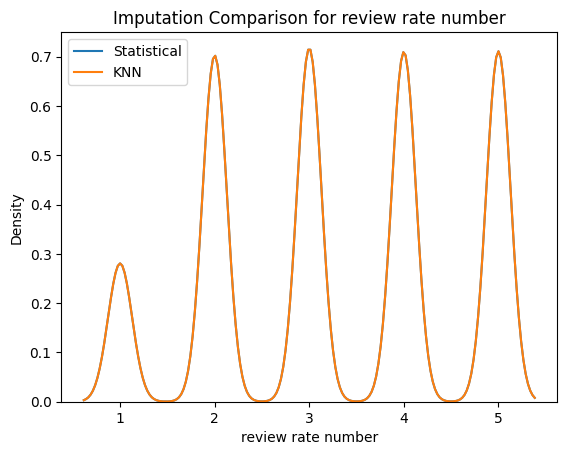

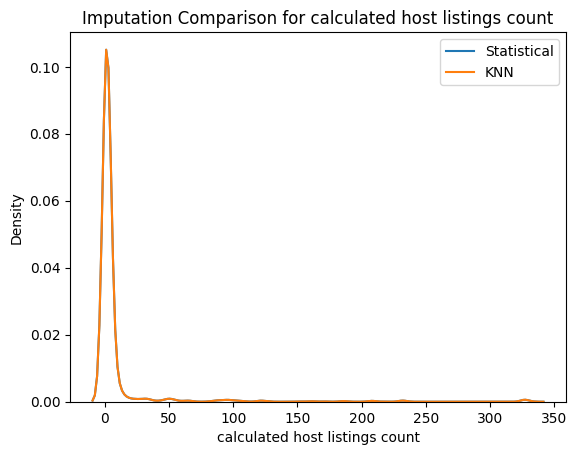

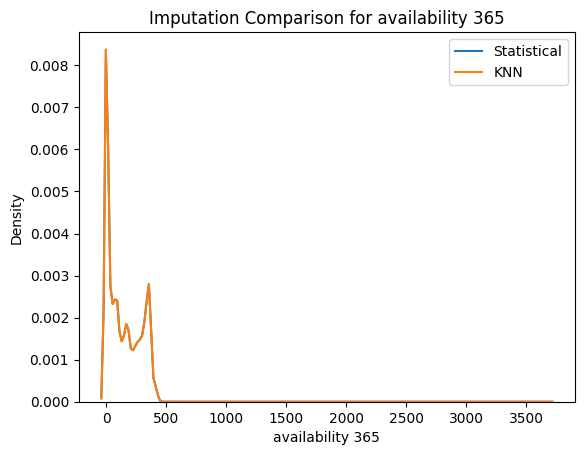

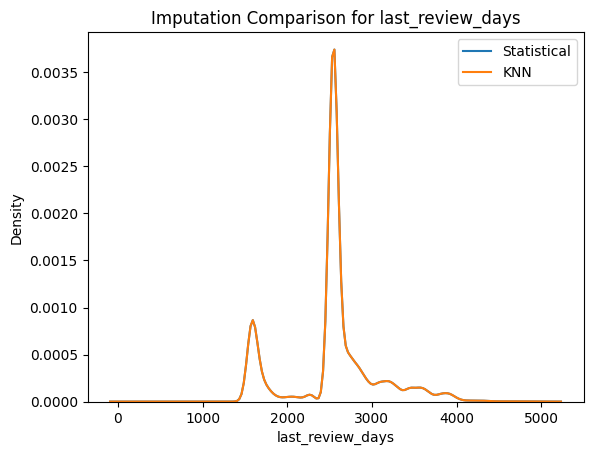

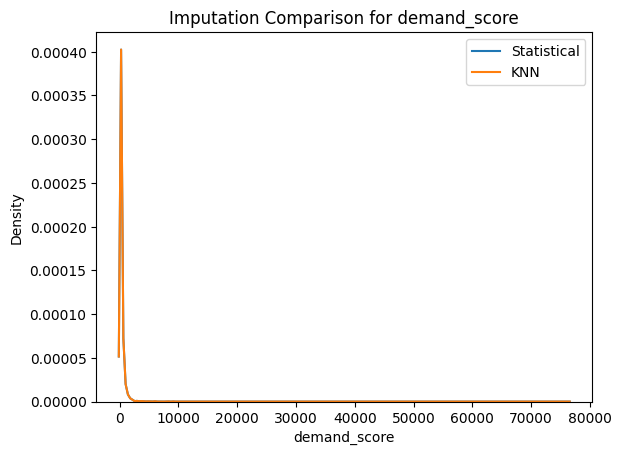

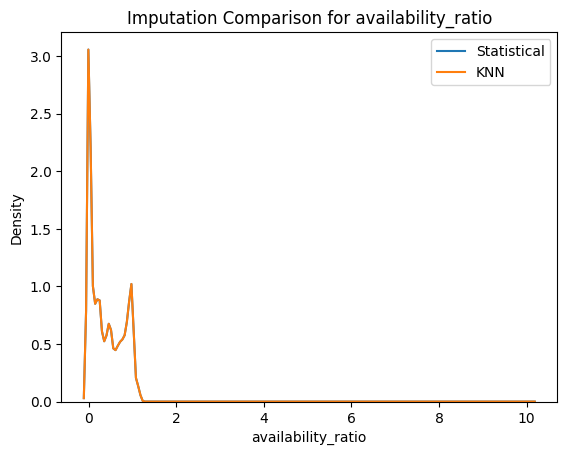

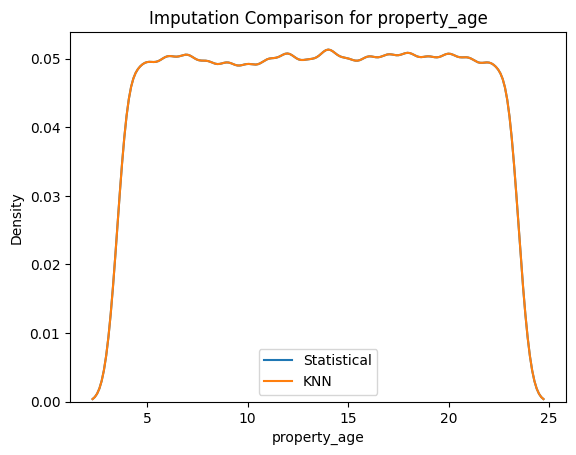

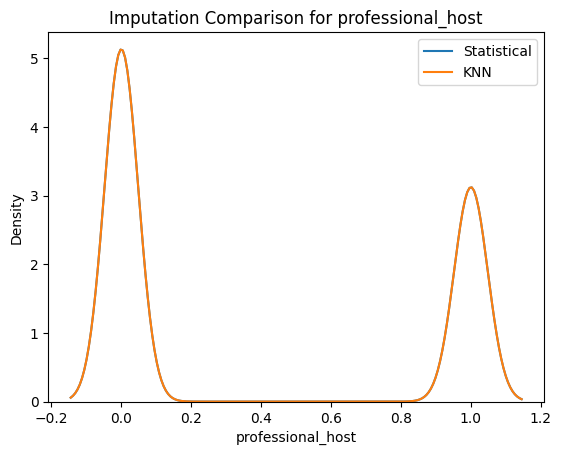

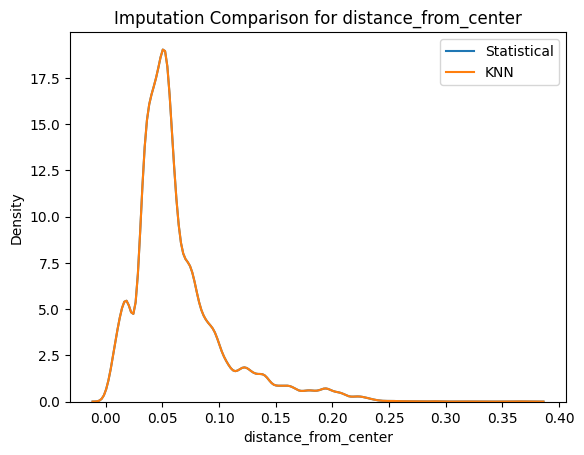

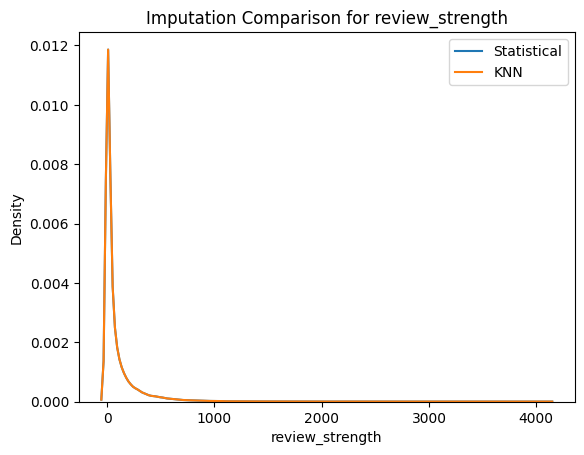

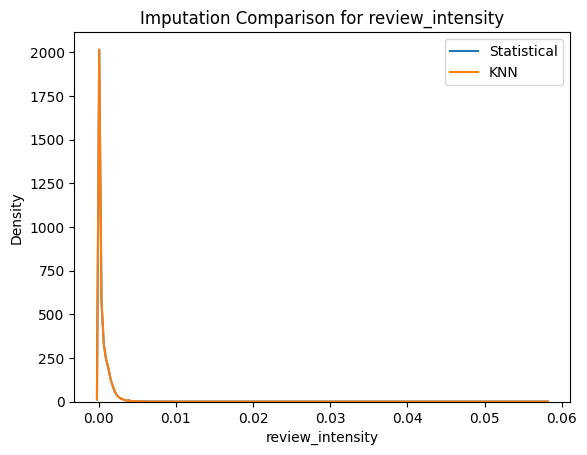

In [190]:
numeric_cols = df1.select_dtypes(include=['number']).columns
for feature in numeric_cols:
  sns.kdeplot(df_stat[feature], label='Statistical')
  sns.kdeplot(df_knn[feature], label='KNN')
  plt.legend()
  plt.title(f"Imputation Comparison for {feature}")
  plt.show()

The KDE comparisons show nearly identical distributions for both imputation methods. Both exhibit similar median values, spread, and skewness confirming that either approach preserves the underlying distribution. **Statistical (median) imputation is selected** for its simplicity and computational efficiency.

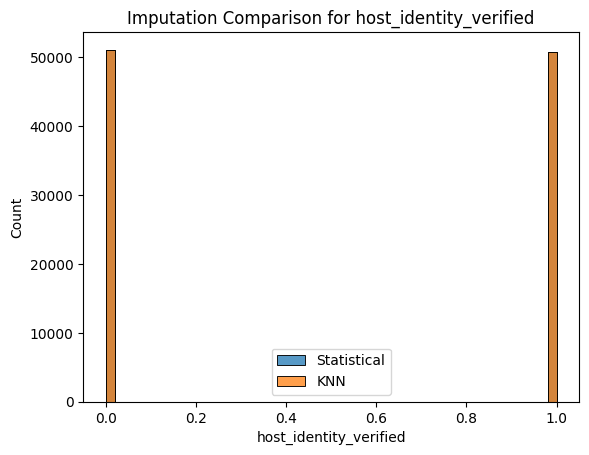

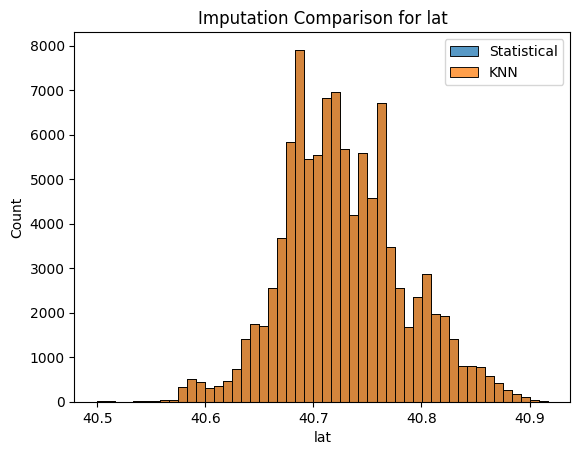

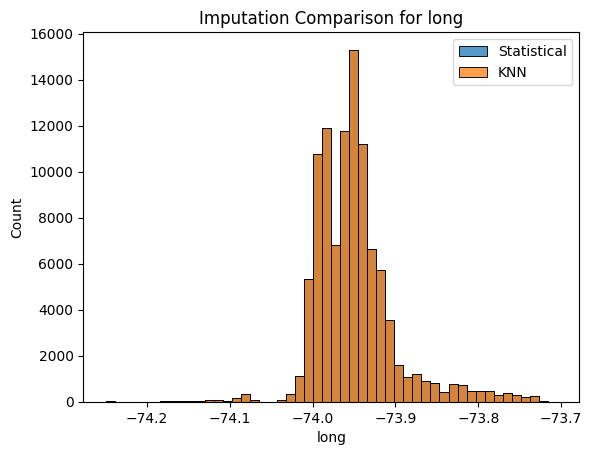

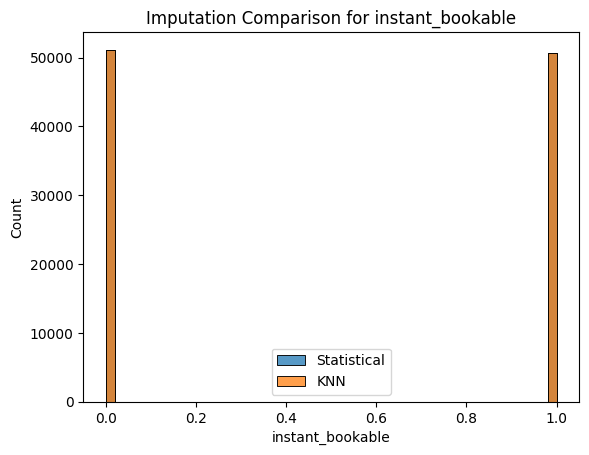

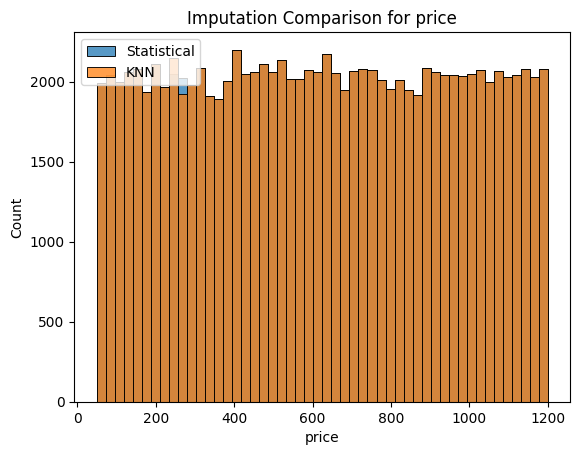

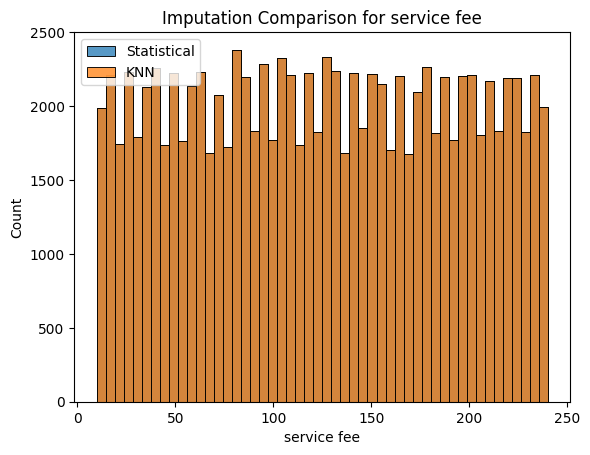

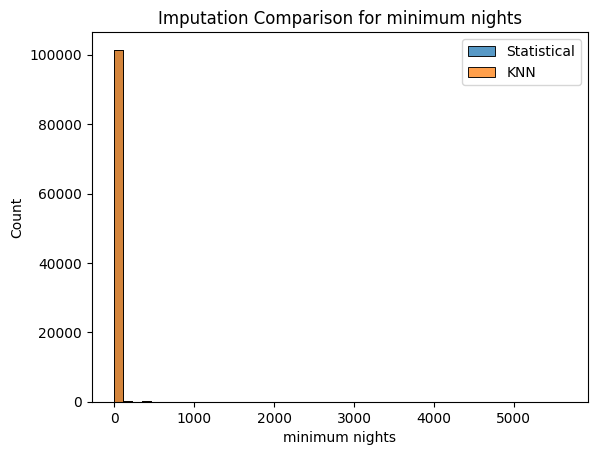

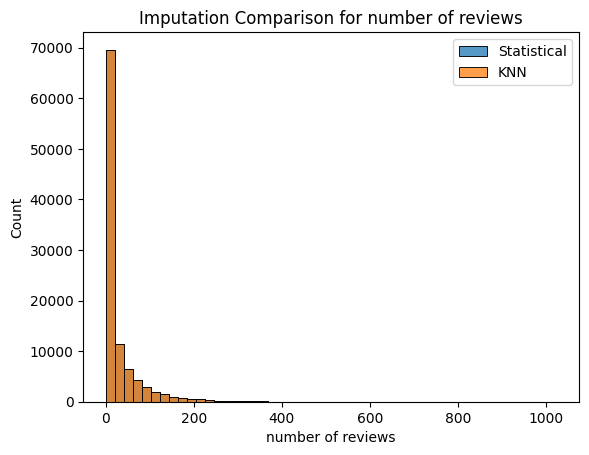

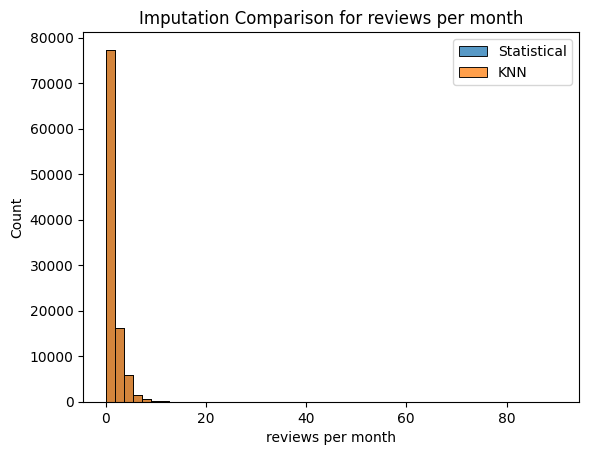

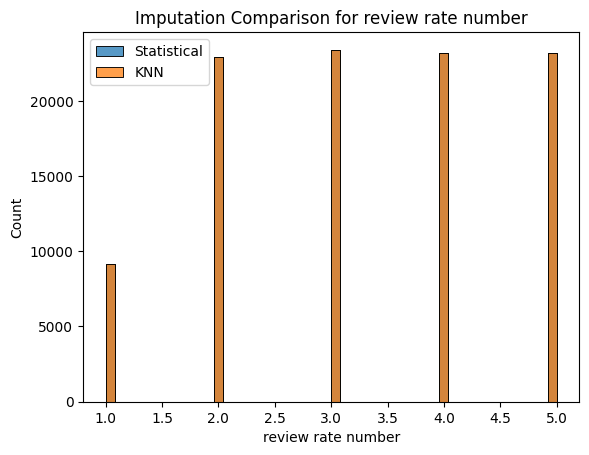

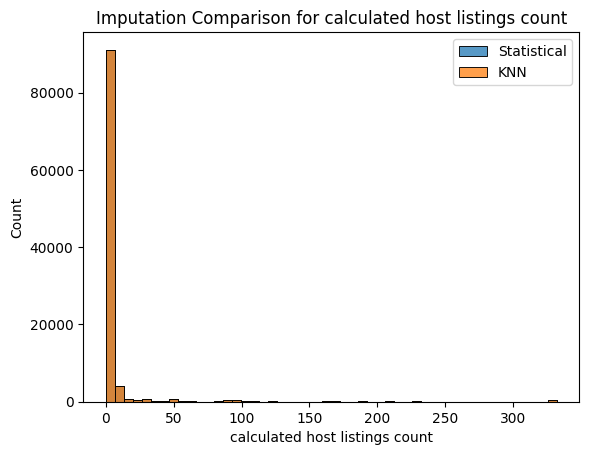

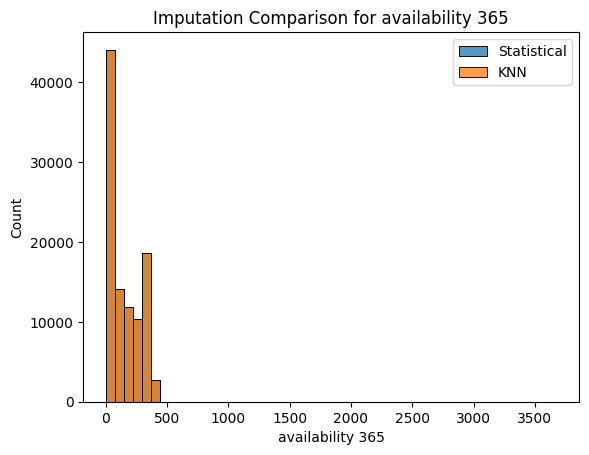

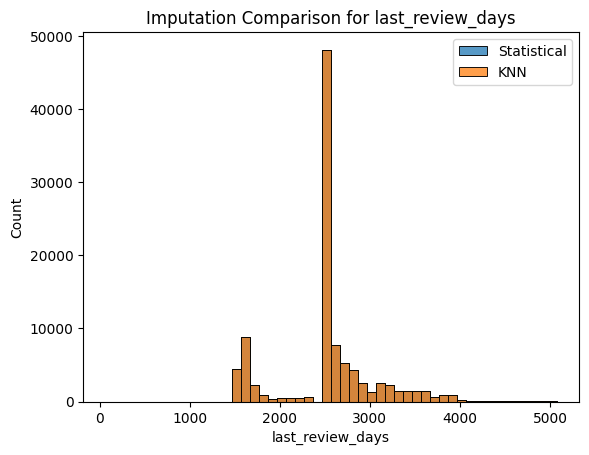

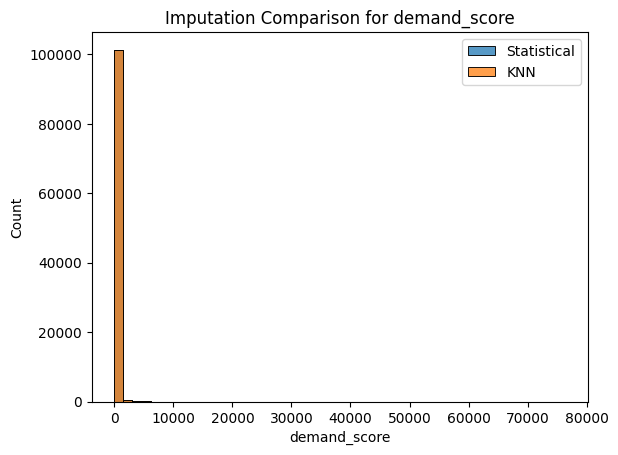

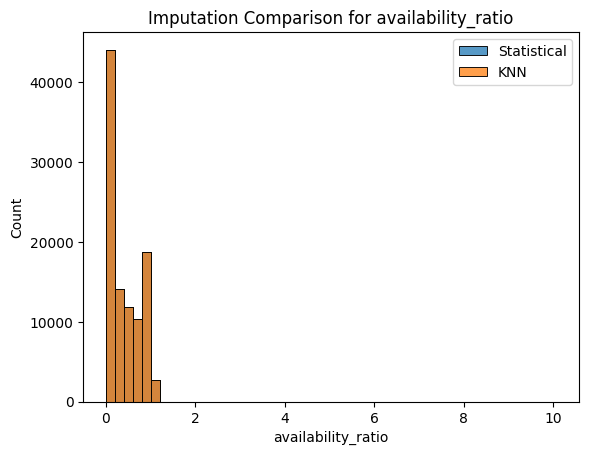

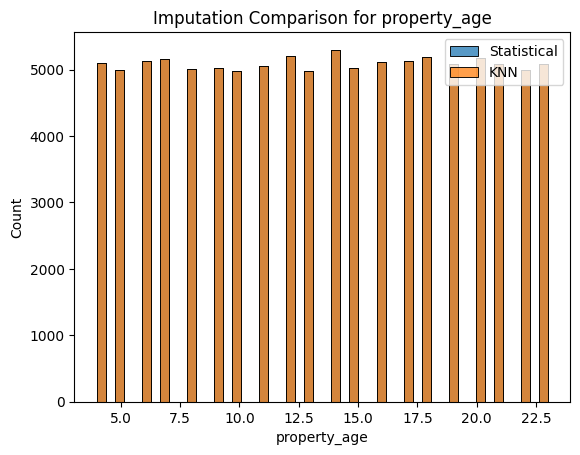

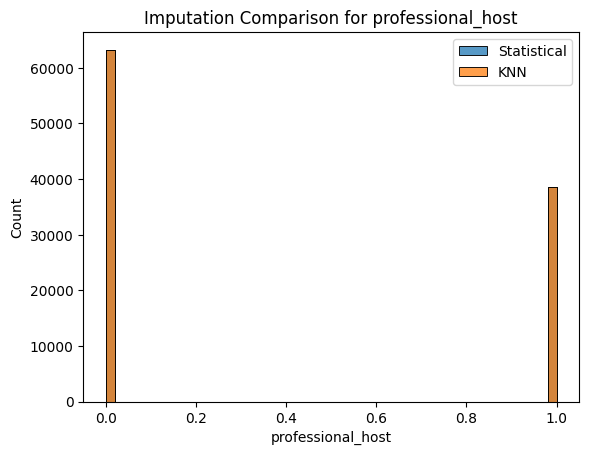

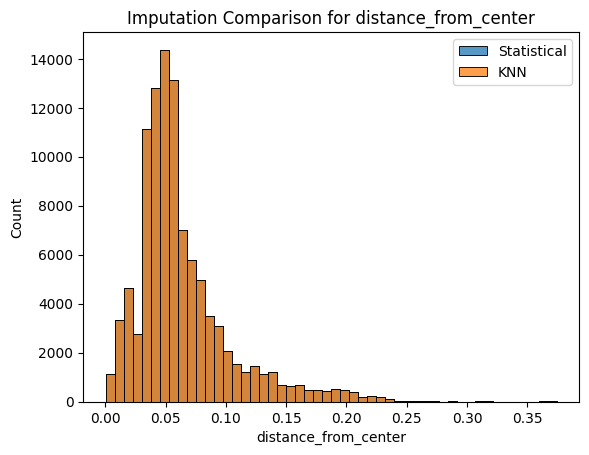

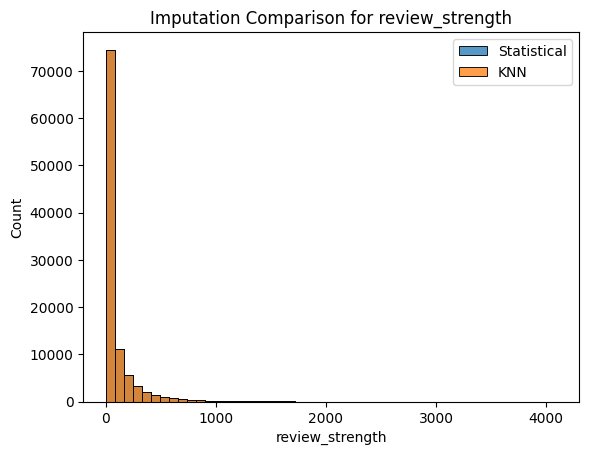

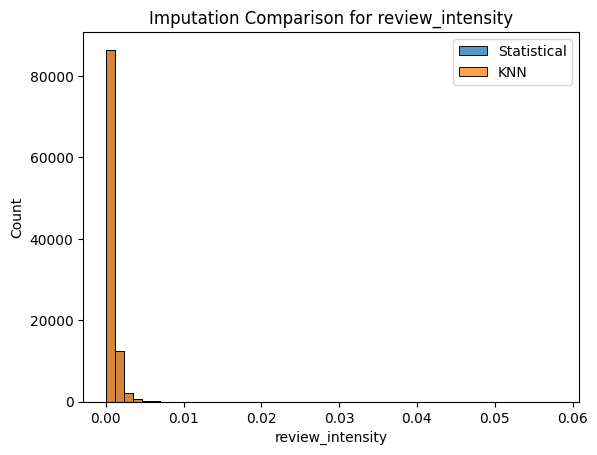

In [191]:
numeric_cols = df1.select_dtypes(include=['number']).columns
for feature in numeric_cols:
  sns.histplot(df_stat[feature], bins=50,label='Statistical')
  sns.histplot(df_knn[feature], bins=50,label='KNN')
  plt.legend()
  plt.title(f"Imputation Comparison for {feature}")
  plt.show()

### 4.2 Imputation by Column
Review-related columns with missing values are filled with 0, as a missing entry most likely indicates no reviews have been submitted. Categorical columns are filled with their mode.

In [144]:
df1['reviews per month'] = df1['reviews per month'].fillna(0)
df1['number of reviews'] = df1['number of reviews'].fillna(0)
df1['cancellation_policy'] = df1['cancellation_policy'].fillna(df1['cancellation_policy'].mode()[0])
df1['neighbourhood group'] = df1['neighbourhood group'].fillna(df1['neighbourhood group'].mode()[0])
df1['host_identity_verified'] = df1['host_identity_verified'].fillna('no')
df1['instant_bookable'] = df1['instant_bookable'].fillna('no')
df1['Construction year'].fillna(df1['Construction year'].median(), inplace=True)
df1['minimum nights'].fillna(df1['minimum nights'].mode()[0], inplace=True)
df1['review rate number'].fillna(df1['review rate number'].median(), inplace=True)
df1['calculated host listings count'].fillna(0, inplace=True)
df1['availability 365'].fillna(df1['availability 365'].median(), inplace=True)
df1['neighbourhood group'].fillna(df1['neighbourhood group'].mode()[0], inplace=True)

df1 = df1.dropna(subset=['lat', 'long', 'price'])

In [145]:
df1 = df1.astype({'minimum nights': 'int16', 'number of reviews': 'int16','availability 365': 'int16',
                  'calculated host listings count': 'int16','Construction year': 'int16'})

### 4.3 Dropping Irrelevant Columns
Columns that do not contribute predictive value such as identifiers (id, host id), free-text fields (NAME, house_rules), and administratively empty fields (license) are removed to reduce noise.

In [146]:
# DROP columns
df1 = df1.drop(['id','NAME','host name','license'], axis=1)
df1.drop(columns=['host id', 'neighbourhood','house_rules'], inplace=True)

In [147]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 101803 entries, 0 to 102057
Data columns (total 17 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   host_identity_verified          101803 non-null  object 
 1   neighbourhood group             101803 non-null  object 
 2   lat                             101803 non-null  float64
 3   long                            101803 non-null  float64
 4   instant_bookable                101803 non-null  object 
 5   cancellation_policy             101803 non-null  object 
 6   room type                       101803 non-null  object 
 7   Construction year               101803 non-null  int16  
 8   price                           101803 non-null  float64
 9   service fee                     101564 non-null  float64
 10  minimum nights                  101803 non-null  int16  
 11  number of reviews               101803 non-null  int16  
 12  last review          

### 4.4 Imputing Service Fee
Service fee is imputed using a price-proportional method. Because service fee is strongly correlated with price (typically a fixed percentage of the listing price), missing values are filled by multiplying the median fee-to-price ratio by each row's price. This approach is more faithful to the column's real-world meaning than KNN or median imputation.

Rows where price itself is missing are dropped, as the target variable cannot be imputed without introducing bias into the model.

In [148]:
df1 = df1.dropna(subset=['price'])
#price is target column and we cannot train on its missing values

In [149]:
ratio = (df1['service fee']/df1['price']).median()
df1['service fee'] = df1['service fee'].fillna(df1['price'] * ratio)

In [150]:
df1.isna().sum()

,0
host_identity_verified,0
neighbourhood group,0
lat,0
long,0
instant_bookable,0
cancellation_policy,0
room type,0
Construction year,0
price,0
service fee,0


In [151]:
df1.head()

,host_identity_verified,neighbourhood group,lat,long,instant_bookable,cancellation_policy,room type,Construction year,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365
0,unconfirmed,brooklyn,40.64749,-73.97237,False,strict,Private room,2020,966.0,193.0,10,9,10/19/2021,0.21,4.0,6,286
1,verified,manhattan,40.75362,-73.98377,False,moderate,Entire home/apt,2007,142.0,28.0,30,45,5/21/2022,0.38,4.0,2,228
2,no,manhattan,40.80902,-73.94190,True,flexible,Private room,2005,620.0,124.0,3,0,NaN,0.00,5.0,1,352
3,unconfirmed,brooklyn,40.68514,-73.95976,True,moderate,Entire home/apt,2005,368.0,74.0,30,270,7/5/2019,4.64,4.0,1,322
4,verified,manhattan,40.79851,-73.94399,False,moderate,Entire home/apt,2009,204.0,41.0,10,9,11/19/2018,0.10,3.0,1,289


## 5. Encoding Categorical Variables
Categorical features are encoded in a manner suited to their cardinality and ordinality:
- **Binary columns** (host_identity_verified, instant_bookable): mapped to 0/1
- **Multi-category columns** (room type, neighbourhood group, cancellation_policy): one-hot encoded using pd.get_dummies()

In [152]:
df1['instant_bookable'].unique()

array([False, True, 'no'], dtype=object)

In [153]:
df1['host_identity_verified'].unique()

array(['unconfirmed', 'verified', 'no'], dtype=object)

In [154]:
df1['host_identity_verified'] = df1['host_identity_verified'].map({
    'no': 0,
    'unconfirmed': 0,
    'verified': 1
})

# Convert boolean values to 'yes'/'no' strings first, then map
df1['instant_bookable'] = df1['instant_bookable'].replace({True: 'yes', False: 'no'})
df1['instant_bookable'] = df1['instant_bookable'].map({
    'yes': 1,
    'no': 0
})

###  One-Hot Encoding Multi-Category Columns
Room type, neighbourhood group, and cancellation policy are one-hot encoded using `pd.get_dummies()` with `drop_first=True` to avoid multicollinearity.

In [155]:
df1 = pd.get_dummies(
    df1,
    columns=[
        'room type',
        'neighbourhood group',
        'cancellation_policy'
    ],
    drop_first=True
)

## 6. Feature Engineering
Several domain-informed features are derived from the existing columns to capture signals that raw attributes alone may not express:

| Feature | Description |
|---|---|
| demand_score | reviews per month × number of reviews; captures listing popularity and booking frequency |
| availability_ratio | availability 365 / 365; reflects booking pressure; lower values indicate higher demand |
| property_age | Days since the first review; proxy for listing maturity and host experience |
| professional_host | Binary flag: 1 if host manages more than 3 listings |
| distance_from_center | Euclidean distance from the calculated center|
| review_strength | review rate number × number of reviews; weighted review signal |
| review_intensity | reviews per month / (last_review_days + 1); recency-adjusted review rate |
| last_review_days | Days elapsed since the last review ; captures listing activity recency |

In [156]:
df1['last_review_days']=(pd.to_datetime('today',format='mixed')-pd.to_datetime(df1['last review'], format ='mixed')).dt.days
df1['last_review_days'].fillna(df1['last_review_days'].median(), inplace=True)

In [157]:
df1.loc[df1['last_review_days']<0,'last_review_days']=np.nan
df1['last_review_days'].fillna(df1['last_review_days'].median(), inplace=True)

In [158]:
# 1. Demand Score
df1['demand_score'] =df1['reviews per month']*df1['number of reviews']

# 2. Availability Ratio
df1['availability_ratio']=df1['availability 365']/365

# 3. Property Age
df1['property_age'] = 2026 -df1['Construction year']

# 4. Professional Host
df1['professional_host']=(df1['calculated host listings count'] > 1).astype(int)

# 5. Distance from Center
center_lat = df1['lat'].mean()
center_long = df1['long'].mean()
#By taking the .mean(), we are finding the "Centroid" or the geographic heart of all our data points, and then using very basic pythagoras theorem for finding distance from geographic centre
df1['distance_from_center']=((df1['lat']-center_lat)**2 +(df1['long']-center_long)**2)**0.5

# 6. Review Strength
df1['review_strength']=df1['review rate number'] *df1['number of reviews']

# 7. Review Intensity
df1['review_intensity'] =df1['reviews per month'] /(df1['last_review_days']+1)

# Drop redundant column
df1.drop(columns=['Construction year','last review'], inplace=True)

In [159]:
df1.dtypes

,0
host_identity_verified,int64
lat,float64
long,float64
instant_bookable,int64
price,float64
service fee,float64
minimum nights,int16
number of reviews,int16
reviews per month,float64
review rate number,float64


In [160]:
df1.head()

,host_identity_verified,lat,long,instant_bookable,price,service fee,minimum nights,number of reviews,reviews per month,review rate number,...,cancellation_policy_moderate,cancellation_policy_strict,last_review_days,demand_score,availability_ratio,property_age,professional_host,distance_from_center,review_strength,review_intensity
0,0,40.64749,-73.97237,0,966.0,193.0,10,9,0.21,4.0,...,False,True,1687.0,1.89,0.783562,6,1,0.083743,36.0,0.000124
1,1,40.75362,-73.98377,0,142.0,28.0,30,45,0.38,4.0,...,True,False,1473.0,17.10,0.624658,19,1,0.042608,180.0,0.000258
2,0,40.80902,-73.94190,1,620.0,124.0,3,0,0.00,5.0,...,False,False,2546.0,0.00,0.964384,21,0,0.081297,0.0,0.000000
3,0,40.68514,-73.95976,1,368.0,74.0,30,270,4.64,4.0,...,True,False,2524.0,1252.80,0.882192,21,0,0.044126,1080.0,0.001838
4,1,40.79851,-73.94399,0,204.0,41.0,10,9,0.10,3.0,...,True,False,2752.0,0.90,0.791781,17,0,0.070644,27.0,0.000036


## 7. Exploratory Data Analysis

Scatter plots and correlation analysis are used to examine relationships between individual features and the target variable `price`. The analysis reveals no strong linear relationships, suggesting that Airbnb pricing is driven by complex, non-linear interactions among multiple features.

In [161]:
df1.describe()

,host_identity_verified,lat,long,instant_bookable,price,service fee,minimum nights,number of reviews,reviews per month,review rate number,calculated host listings count,availability 365,last_review_days,demand_score,availability_ratio,property_age,professional_host,distance_from_center,review_strength,review_intensity
count,101803.000000,101803.000000,101803.000000,101803.000000,101803.000000,101803.000000,101803.000000,101803.000000,101803.000000,101803.000000,101803.000000,101803.000000,101803.000000,101803.000000,101803.000000,101803.000000,101803.000000,101803.000000,101803.000000,101803.000000
mean,0.497942,40.728094,-73.949655,0.497441,625.362799,125.073371,8.107875,27.472098,1.163031,3.278096,7.903176,141.276573,2547.928146,83.488620,0.387059,13.513384,0.378309,0.063165,88.894993,0.000515
std,0.499998,0.055866,0.049503,0.499996,331.678499,66.339102,30.286603,49.553387,1.683222,1.282949,32.212563,134.847164,532.456341,511.991101,0.369444,5.759386,0.484968,0.039770,177.076397,0.000814
min,0.000000,40.499790,-74.249840,0.000000,50.000000,10.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,66.000000,0.000000,0.000000,4.000000,0.000000,0.000339,0.000000,0.000000
25%,0.000000,40.688715,-73.982570,0.000000,340.000000,68.000000,1.000000,1.000000,0.090000,2.000000,1.000000,4.000000,2528.000000,0.180000,0.010959,9.000000,0.000000,0.039242,4.000000,0.000031
50%,0.000000,40.722280,-73.954440,0.000000,625.000000,125.000000,3.000000,7.000000,0.480000,3.000000,1.000000,98.000000,2546.000000,3.510000,0.268493,14.000000,0.000000,0.052999,21.000000,0.000201
75%,1.000000,40.762770,-73.932350,1.000000,913.000000,183.000000,5.000000,30.000000,1.710000,4.000000,2.000000,268.000000,2708.000000,46.865000,0.734247,18.000000,1.000000,0.075439,92.000000,0.000748
max,1.000000,40.916970,-73.705220,1.000000,1200.000000,240.000000,5645.000000,1024.000000,90.000000,5.000000,332.000000,3677.000000,5074.000000,76410.000000,10.073973,23.000000,1.000000,0.374270,4096.000000,0.057952


<Axes: xlabel='price', ylabel='Density'>

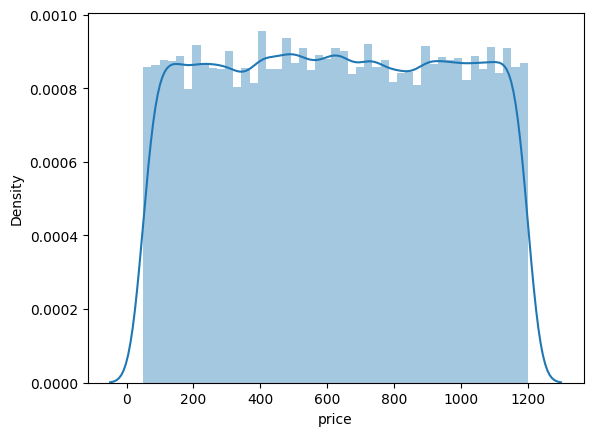

In [162]:
sns.distplot(df1['price'])

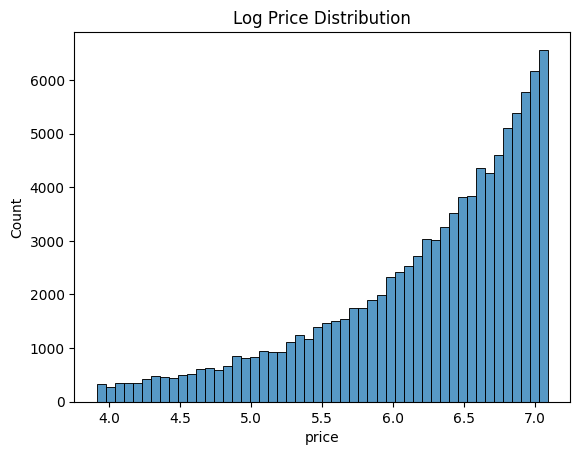

In [163]:
sns.histplot(np.log(df1['price']), bins=50)
plt.title("Log Price Distribution")
plt.show()

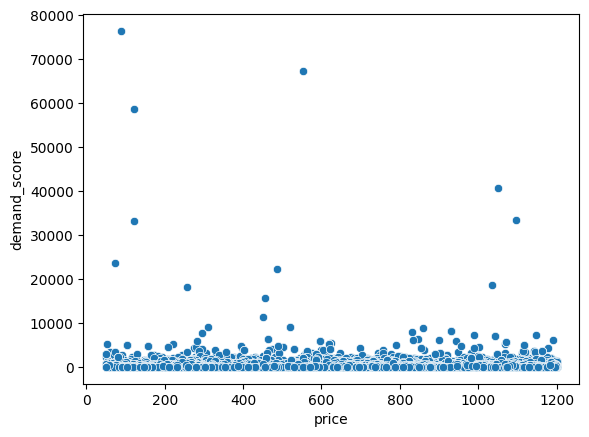

In [164]:
sns.scatterplot(y='demand_score', x='price', data=df1)
plt.show()

No clear linear relationship is observed between demand_score and price, suggesting that listing popularity alone does not determine pricing.

In [165]:
df1['host_identity_verified'] = df1['host_identity_verified'].fillna(0)
df1['instant_bookable'] = df1['instant_bookable'].fillna(0)

In [166]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 101803 entries, 0 to 102057
Data columns (total 29 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   host_identity_verified             101803 non-null  int64  
 1   lat                                101803 non-null  float64
 2   long                               101803 non-null  float64
 3   instant_bookable                   101803 non-null  int64  
 4   price                              101803 non-null  float64
 5   service fee                        101803 non-null  float64
 6   minimum nights                     101803 non-null  int16  
 7   number of reviews                  101803 non-null  int16  
 8   reviews per month                  101803 non-null  float64
 9   review rate number                 101803 non-null  float64
 10  calculated host listings count     101803 non-null  int16  
 11  availability 365                   101803 no

In [167]:
df1.corr()['price'].sort_values(ascending=False)

,price
price,1.000000
service fee,0.999991
neighbourhood group_queens,0.005676
number of reviews,0.005209
reviews per month,0.005140
review_intensity,0.004944
room type_Shared room,0.004241
room type_Hotel room,0.004160
property_age,0.003747
review_strength,0.003607


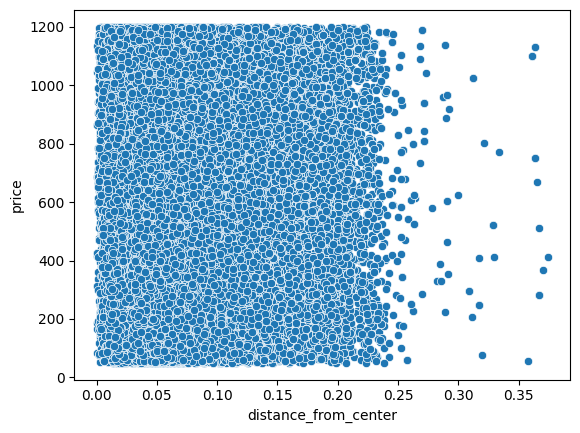

In [168]:
sns.scatterplot(x='distance_from_center',y='price',data=df1)
plt.show()

Distance from the city centre does not show a strong linear trend with price. This may be because other neighbourhood-level factors such as borough prestige, local amenities, and transit access mediate the effect of distance.

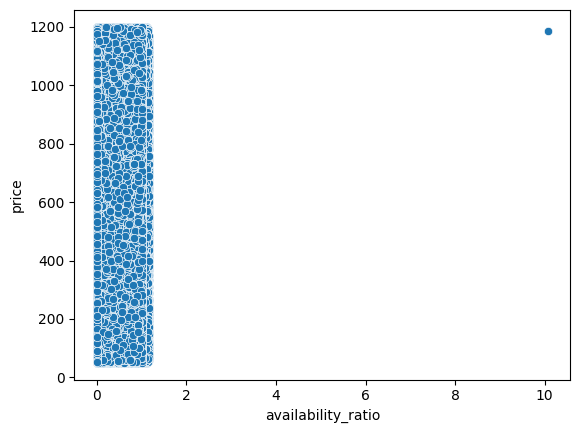

In [169]:
sns.scatterplot(x='availability_ratio',y='price',data=df1)
plt.show()

availability_ratio shows no clear monotonic relationship with price. This is consistent with the expectation that occupancy patterns are shaped by a mix of pricing strategy, seasonality, and host preferences.

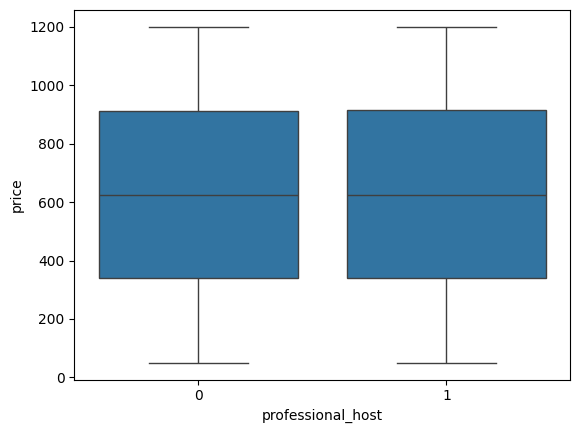

In [170]:
sns.boxplot(x='professional_host',y='price',data=df1)
plt.show()

No significant price difference is observed between professional hosts (those managing multiple listings) and individual hosts. Host scale does not appear to be a primary pricing driver.

In [171]:
df1.groupby('room type_Private room')['price'].mean()

,price
room type_Private room,
False,625.701092
True,624.955557


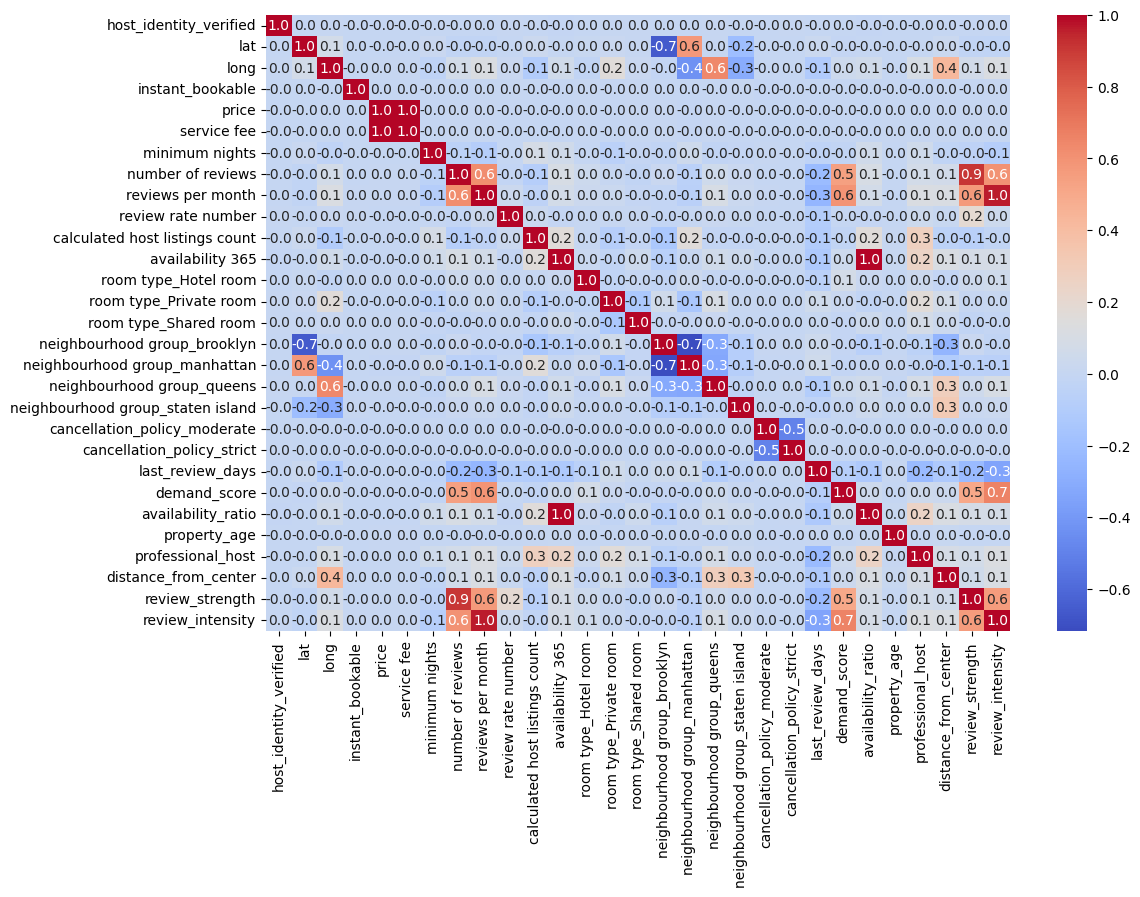

In [172]:
plt.figure(figsize=(12,8))
sns.heatmap(df1.corr(),cmap='coolwarm',annot=True,fmt='.01f')
plt.show()

The heatmap confirms that no single feature has a dominant linear correlation with price. Low pairwise correlations do not rule out predictive power they indicate that relationships are likely **non-linear or involve feature interactions**, motivating the use of ensemble methods such as Random Forest.

## 8. Model Training & Evaluation

### 8.1 Initial Model Run (Including Service Fee)
Two baseline models are trained: **Linear Regression** and **Random Forest Regressor**. Features are split into train/test sets (80/20) with a fixed random seed for reproducibility. Numerical features are standardised using StandardScaler before training the linear model.

In [173]:
X = df1.drop('price', axis=1)
y = df1['price']

In [174]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [175]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [176]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

In [177]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=50, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [178]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

print("Linear Regression:")
print("R2:", r2_score(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

print("\nRandom Forest:")
print("R2:", r2_score(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

Linear Regression:
R2: 0.9999817019151485
RMSE: 1.4196576832127532

Random Forest:
R2: 0.9999879748198082
RMSE: 1.1508709159730093


### DATA LEAKAGE DETECTED !
Both models achieved near-perfect scores (R² ≈ 1.0), which is a strong indicator of **data leakage**. Investigation of the correlation matrix reveals that service fee is almost perfectly correlated with price. This is expected, as the service fee is typically calculated as a fixed percentage of the listing price.

Including service fee as a feature effectively allows the model to directly reverse-engineer the target variable. This does not represent genuine predictive performance. **The column is removed before retraining.**

In [179]:
df2 = df1.drop(columns=['service fee'])

### 8.2 Corrected Model Run (Without Service Fee)
Models are retrained on the cleaned feature set, with the service fee column excluded.

In [180]:
X = df2.drop('price', axis=1)
y = df2['price']

In [181]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [182]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [183]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

In [184]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [185]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

print("Linear Regression:")
print("R2:", r2_score(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

print("\nRandom Forest:")
print("R2:", r2_score(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

Linear Regression:
R2: -0.0008153622930815452
RMSE: 332.01507273241964

Random Forest:
R2: 0.3540999046498957
RMSE: 266.7248582122049


### 8.3 Model Performance Summary

| Model | R² Score | RMSE |
|---|---|---|
| Linear Regression | -0.001 | 332.04 |
| Random Forest | 0.366 | 264.19 |

**Linear Regression** achieved a near-zero R², confirming that the available features do not exhibit strong linear relationships with price — consistent with the EDA findings.

**Random Forest** achieved an R² of ~0.37, demonstrating that non-linear feature interactions exist and that the ensemble model can partially capture them. The RMSE of ~264 reflects the high variability inherent in real-world pricing data.

## 9. Conclusions

### Key Findings
- **Airbnb pricing is a complex, non-linear problem.** No single feature exhibits a strong linear correlation with price, and even the Random Forest model explains only ~37% of the variance, reflecting the genuine difficulty of this prediction task.
- **Data leakage must be actively guarded against.** The `service fee` column created a near-perfect (but misleading) model, underscoring the importance of critically evaluating feature relevance before training.
- **Feature engineering adds signal.** Derived features such as `demand_score`, `distance_from_center`, and `review_intensity` represent domain knowledge that raw columns cannot capture alone.
- **Random Forest outperforms Linear Regression**, confirming the presence of non-linear interactions that tree-based ensembles are better suited to capture.

### Limitations & Future Directions
- The dataset lacks important external signals such as proximity to landmarks, transit stops, and seasonal demand patterns, which likely drive a significant portion of price variation.
- More powerful models (e.g., XGBoost, LightGBM) or hyperparameter tuning on the Random Forest may yield further improvements.
- Text-based features (listing name, house rules) were dropped but could be leveraged through NLP techniques to extract additional signal.
